*   Qingyi (Freda) Song Drechsler's code on Momentum  
* based on CRSP data and Jegadeesh & Titman (1993) Momentum Portfolio
*  https://www.fredasongdrechsler.com/python-code/momentum

In [1]:
# 1) First, As always, import the various Python data packages and establish connection with WRDS server 

import pandas as pd
import numpy as np
import wrds                          # Install it via Spyder by typing:  pip install wrds
import matplotlib.pyplot as plt
from pandas.tseries.offsets import *
from scipy import stats

###################
# Connect to WRDS #;  it will prompt fpr enter user name and password 
###################
conn=wrds.Connection()     #it will prompt fpr enter user name and password

Enter your WRDS username [mikehe]:hesongrun
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
Loading library list...
Done


In the following coding block, we obtain the monthly stock trading files from the CRSP database. Here are the filters we used:

*   Date filter: trading date between 01/01/1963 and 12/31/1989
*   Exchange filter: exchange code between -2 and 2
*   Share class filter: share class between 10 and 11

Some of the above filters involve the CRSP msenames table, which is why in the sql code we are merging the table msf and msenames. 


In [2]:
# 2)  The next step is to extract data from CRSP database

###################
# CRSP Block      #
###################
# sql similar to crspmerge macro
# added exchcd=-2,-1,0 to address the issue that stocks temp stopped trading
# without exchcd=-2,-1, 0 the non-trading months will be tossed out in the output
# leading to wrong cumret calculation in momentum step
# Code  Definition
# -2 Halted by the NYSE or AMEX
# -1 Suspended by the NYSE, AMEX, or NASDAQ
# 0 Not Trading on NYSE, AMEX, or NASDAQ
# 1 New York Stock Exchange
# 2 American Stock Exchange

crsp_m = conn.raw_sql("""
                      select a.permno, a.permco, b.ncusip, a.date, 
                      b.shrcd, b.exchcd, b.siccd,
                      a.ret, a.vol, a.shrout, a.prc, a.cfacpr, a.cfacshr
                      from crsp.msf as a
                      left join crsp.msenames as b
                      on a.permno=b.permno
                      and b.namedt<=a.date
                      and a.date<=b.nameendt
                      where a.date between '01/01/1963' and '12/31/1989'
                      and b.exchcd between -2 and 2
                      and b.shrcd between 10 and 11
                      """) 

In the CRSP database, the security identifier is the five digit permno (standing for permanent number, which is the unique identifier for each security and will not be reused). The main variables in the table below we need to use are: permno, date, and ret.

In [3]:
crsp_m.head(5)

,permno,permco,ncusip,date,shrcd,exchcd,siccd,ret,vol,shrout,prc,cfacpr,cfacshr
0,24221.0,20258.0,None,1963-01-31,11.0,1.0,4931.0,0.076628,662.0,14390.0,35.125,3.020155,3.00000
1,24248.0,21206.0,None,1963-01-31,11.0,1.0,4911.0,-0.014663,140.0,1716.0,42.000,7.038852,2.66664
2,24256.0,21215.0,None,1963-01-31,11.0,1.0,4911.0,0.030612,203.0,7608.0,37.875,4.000000,4.00000
3,11113.0,22249.0,None,1963-01-31,10.0,1.0,2328.0,0.000000,790.0,2356.0,4.250,1.017946,1.00000
4,10006.0,22156.0,None,1963-01-31,10.0,1.0,3743.0,0.047002,506.0,1453.0,80.750,6.000000,6.00000


Note that the datatype of the date variable is string. We need to convert it to datetime type. To do this, we call the function pd.to_datetime()

In [4]:
print(crsp_m['date'].dtype)

object


In [5]:
# Change variable format to int
crsp_m[['permco','permno','shrcd','exchcd']]=\
    crsp_m[['permco','permno','shrcd','exchcd']].astype(int)

# Line up date to be end of month
crsp_m['date']=pd.to_datetime(crsp_m['date'])
    
print('Done Step 2:  extract  data  \n')

Done Step 2:  extract  data  



In [6]:
 # 3)  With the data ready, then calculate the cumulative return by summing log returns.
          #There can be many other methods to arrive at the same goal. 
    
#######################################################
# Create Momentum Portfolio                           #
# Measures Based on Past (J) Month Compounded Returns #
#######################################################

J = 6 # Formation Period Length: J can be between 3 to 12 months
K = 6 # Holding Period Length: K can be between 3 to 12 months

# Sort the crsp_m by permno and date, use date as dataframe index
_tmp_crsp = crsp_m[['permno','date','ret']].sort_values(['permno','date'])\
    .set_index('date')

_tmp_crsp.head(10)

,permno,ret
date,,
1963-01-31,10006,0.047002
1963-02-28,10006,0.038700
1963-03-29,10006,-0.009009
1963-04-30,10006,0.084848
1963-05-31,10006,0.091620
1963-06-28,10006,-0.001289
1963-07-31,10006,-0.045161
1963-08-30,10006,0.121081
1963-09-30,10006,-0.077670


The momentum portfolio is formed based on the past J month cumulative returns. 
$$
    cumret_{i,t} = \prod_{j = 0}^{J-1} (1 + R_{i, t-j})
$$
For computational efficiency, we apply the log trick:
$$
    log(cumret_{i,t}) = \sum_{j =0}^{J-1} log(1 + R_{i, t-j})
$$
which transforms the rolling product into a rolling sum.

In [7]:
# Replace missing return with 0
_tmp_crsp['ret']=_tmp_crsp['ret'].fillna(0)

# Calculate rolling cumulative return
# by summing log(1+ret) over the formation period
_tmp_crsp['logret']=np.log(1+_tmp_crsp['ret'])
umd = _tmp_crsp.groupby(['permno'])['logret'].rolling(J, min_periods=J).sum()
umd = umd.reset_index()
umd['cumret']=np.exp(umd['logret'])-1

print('Done Step 3:  compute the returns  \n')
umd.head(10)

Done Step 3:  compute the returns  



,permno,date,logret,cumret
0,10006,1963-01-31,NaN,NaN
1,10006,1963-02-28,NaN,NaN
2,10006,1963-03-29,NaN,NaN
3,10006,1963-04-30,NaN,NaN
4,10006,1963-05-31,NaN,NaN
5,10006,1963-06-28,0.242664,0.274640
6,10006,1963-07-31,0.150521,0.162439
7,10006,1963-08-30,0.226845,0.254635
8,10006,1963-09-30,0.155042,0.167707
9,10006,1963-10-31,0.129883,0.138695


The next step is to form 10 momentum portfolios based on the past J month cumulative returns. 

Here we will use a function pd.qcut. It discretize variable into equal-sized buckets based on rank or sample quantile.

Here is an example:

In [8]:
pd.qcut(range(5), 4, labels=False) # array([0, 0, 1, 2, 3])

array([0, 0, 1, 2, 3])

In [9]:
# 4)  Form momentum portfolios

########################################
# Formation of 10 Momentum Portfolios  #
########################################

# For each date: assign ranking 1-10 based on cumret
# 1=lowest 10=highest cumret

umd=umd.dropna(axis=0, subset=['cumret'])
umd['momr']=umd.groupby('date')['cumret'].transform(lambda x: pd.qcut(x, 10, labels=False))

umd.momr=umd.momr.astype(int)
umd['momr'] = umd['momr']+1

Next, we are going to hold the current portfolio for $K$ months. To do this, we first calculate the holding start date 'hdate1' and holding end date 'hdate2' of each portfolios. To do this, we rely on pandas.tseries.offset. 

To understand how these offsets work, you may refer to this documentation:
https://pandas.pydata.org/docs/reference/api/pandas.tseries.offsets.DateOffset.html

In [10]:
# Corrected previous version month end line up issue
# First lineup date to month end date medate
# Then calculate hdate1 and hdate2 using medate

umd['form_date'] = umd['date']
umd['medate'] = umd['date']+MonthEnd(0)
umd['hdate1']=umd['medate']+MonthBegin(1)
umd['hdate2']=umd['medate']+MonthEnd(K)
umd = umd[['permno', 'form_date','momr','hdate1','hdate2']]

In [13]:
umd.head(5)

,permno,form_date,momr,hdate1,hdate2
5,10006,1963-06-28,9,1963-07-01,1963-12-31
6,10006,1963-07-31,9,1963-08-01,1964-01-31
7,10006,1963-08-30,9,1963-09-01,1964-02-29
8,10006,1963-09-30,8,1963-10-01,1964-03-31
9,10006,1963-10-31,8,1963-11-01,1964-04-30


Next, at each month $t$, we need to merge each asset with returns of all active months of this asset (the month $t$ is within the holding month range of the asset). 
* This step is highly memory consuming

In [11]:
# join rank and return data together
# note: this step consumes a lot of memory so takes a while
_tmp_ret = crsp_m[['permno','date','ret']]
# A wild merge of asset at time t with all its past, present, and future returns
port = pd.merge(_tmp_ret, umd, on=['permno'], how='inner')

# Keep only the active assets (date within the holding period range)
port = port[(port['hdate1']<=port['date']) & (port['date']<=port['hdate2'])]

In [12]:
port.head(5)

,permno,date,ret,form_date,momr,hdate1,hdate2
1914,24221,1963-07-31,-0.043165,1963-06-28,5,1963-07-01,1963-12-31
2233,24221,1963-08-30,0.063910,1963-06-28,5,1963-07-01,1963-12-31
2234,24221,1963-08-30,0.063910,1963-07-31,4,1963-08-01,1964-01-31
2552,24221,1963-09-30,0.029965,1963-06-28,5,1963-07-01,1963-12-31
2553,24221,1963-09-30,0.029965,1963-07-31,4,1963-08-01,1964-01-31


Next, we compute the equal-weighted return to the momentum portfolios grouped into different momentum deciles, form date at each date.

In [15]:
umd2 = port.sort_values(by=['date','momr','form_date','permno']).drop_duplicates()
umd3 = umd2.groupby(['date','momr','form_date'])['ret'].mean().reset_index()
umd3.head(20)

,date,momr,form_date,ret
0,1963-07-31,1,1963-06-28,0.002720
1,1963-07-31,2,1963-06-28,-0.007838
2,1963-07-31,3,1963-06-28,-0.010018
3,1963-07-31,4,1963-06-28,-0.005044
4,1963-07-31,5,1963-06-28,-0.002754
5,1963-07-31,6,1963-06-28,-0.001859
6,1963-07-31,7,1963-06-28,-0.013522
7,1963-07-31,8,1963-06-28,-0.016332
8,1963-07-31,9,1963-06-28,-0.004868
9,1963-07-31,10,1963-06-28,-0.001270


The final momentum portfolio is calculated as an average of portfolios formed in the past $K$ months
$$
    finalport_{i,t} = \frac{1}{K}\sum_{k = 0}^{K-1}momport_{form date = t-k}
$$

In [18]:
# Skip first two years of the sample 
start_yr = umd3['date'].dt.year.min()+2
umd3 = umd3[umd3['date'].dt.year>=start_yr]
umd3 = umd3.sort_values(by=['date','momr'])

# Create one return series per MOM group every month
ewret = umd3.groupby(['date','momr'])['ret'].mean().reset_index()  

Summary statistics for the momentum decile portolios

In [19]:
ewstd = umd3.groupby(['date','momr'])['ret'].std().reset_index()   
ewret = ewret.rename(columns={'ret':'ewret'})
ewstd = ewstd.rename(columns={'ret':'ewretstd'})
ewretdat = pd.merge(ewret, ewstd, on=['date','momr'], how='inner')
ewretdat = ewretdat.sort_values(by=['momr'])

print('Done Step 4:  Summary stats of Momentum Decile Portfolio  \n') 

# portfolio summary
ewretdat.groupby(['momr'])['ewret'].describe()[['count','mean', 'std']]

Done Step 4:  Summary stats of Momentum Decile Portfolio  



,count,mean,std
momr,,,
1,252.0,0.004935,0.090005
2,252.0,0.009027,0.073160
3,252.0,0.010975,0.067518
4,252.0,0.010972,0.063158
5,252.0,0.011553,0.060842
6,252.0,0.012224,0.058976
7,252.0,0.012048,0.058329
8,252.0,0.012351,0.059166
9,252.0,0.012888,0.061523


Finally, we calculate cumulative returns to the top decile (winners) and the bottom decile (losers). 

In [21]:
# 5)  Calculate long winners-short losers strategy and report portfolio statistics

#################################
# Long-Short Portfolio Returns  #
#################################
ewretdat.head(5)

,date,momr,ewret,ewretstd
0,1969-01-31,1,-0.007038,0.004903
2420,1989-03-31,1,0.000382,0.006354
970,1977-02-28,1,-0.022372,0.005381
960,1977-01-31,1,0.058064,0.017856
950,1976-12-31,1,0.142445,0.021595


In [22]:
# Transpose portfolio layout to have columns as portfolio returns
ewretdat2 = ewretdat.pivot(index='date', columns='momr', values='ewret')
ewretdat2.head(5)

momr,1,2,3,4,5,6,7,8,9,10
date,,,,,,,,,,
1969-01-31,-0.007038,0.000684,-0.000586,-0.002375,0.000432,-0.005882,-0.004370,-0.003964,-0.005491,-0.002636
1969-02-28,-0.102611,-0.081529,-0.072563,-0.074486,-0.069964,-0.075827,-0.080269,-0.087790,-0.097878,-0.121549
1969-03-28,0.001012,0.006006,0.002345,0.007710,0.010029,0.015070,0.021490,0.033551,0.035917,0.062239
1969-04-30,-0.014080,-0.001240,0.001717,-0.001810,0.000646,0.007798,0.005958,0.009400,0.007271,0.022100
1969-05-29,-0.001094,-0.000805,0.001344,0.001243,-0.000268,0.004589,0.002985,0.004657,0.007261,0.027662


In [20]:
# Add prefix port in front of each column
ewretdat2 = ewretdat2.add_prefix('port')
ewretdat2 = ewretdat2.rename(columns={'port1':'losers', 'port10':'winners'})
ewretdat2['long_short'] = ewretdat2['winners'] - ewretdat2['losers']

# Compute Long-Short Portfolio Cumulative Returns
ewretdat3 = ewretdat2
ewretdat3['1+losers']=1+ewretdat3['losers']
ewretdat3['1+winners']=1+ewretdat3['winners']
ewretdat3['1+ls'] = 1+ewretdat3['long_short']

ewretdat3['cumret_winners']=ewretdat3['1+winners'].cumprod()-1
ewretdat3['cumret_losers']=ewretdat3['1+losers'].cumprod()-1
ewretdat3['cumret_long_short']=ewretdat3['1+ls'].cumprod()-1

ewretdat3.head(5)

momr,losers,port2,port3,port4,port5,port6,port7,port8,port9,winners,long_short,1+losers,1+winners,1+ls,cumret_winners,cumret_losers,cumret_long_short
date,,,,,,,,,,,,,,,,,
1969-01-31,-0.007038,0.000684,-0.000586,-0.002375,0.000432,-0.005882,-0.004370,-0.003964,-0.005491,-0.002636,0.004403,0.992962,0.997364,1.004403,-0.002636,-0.007038,0.004403
1969-02-28,-0.102611,-0.081529,-0.072563,-0.074486,-0.069964,-0.075827,-0.080269,-0.087790,-0.097878,-0.121549,-0.018938,0.897389,0.878451,0.981062,-0.123865,-0.108928,-0.014619
1969-03-28,0.001012,0.006006,0.002345,0.007710,0.010029,0.015070,0.021490,0.033551,0.035917,0.062239,0.061227,1.001012,1.062239,1.061227,-0.069335,-0.108026,0.045713
1969-04-30,-0.014080,-0.001240,0.001717,-0.001810,0.000646,0.007798,0.005958,0.009400,0.007271,0.022100,0.036180,0.985920,1.022100,1.036180,-0.048768,-0.120585,0.083547
1969-05-29,-0.001094,-0.000805,0.001344,0.001243,-0.000268,0.004589,0.002985,0.004657,0.007261,0.027662,0.028757,0.998906,1.027662,1.028757,-0.022454,-0.121547,0.114706


In [23]:
#################################
# Portfolio Summary Statistics  #
################################# 

# Mean 
mom_mean = ewretdat3[['winners', 'losers', 'long_short']].mean().to_frame()
mom_mean = mom_mean.rename(columns={0:'mean'}).reset_index()

# T-Value and P-Value
t_losers = pd.Series(stats.ttest_1samp(ewretdat3['losers'],0.0)).to_frame().T
t_winners = pd.Series(stats.ttest_1samp(ewretdat3['winners'],0.0)).to_frame().T
t_long_short = pd.Series(stats.ttest_1samp(ewretdat3['long_short'],0.0)).to_frame().T

t_losers['momr']='losers'
t_winners['momr']='winners'
t_long_short['momr']='long_short'

t_output =pd.concat([t_winners, t_losers, t_long_short])\
    .rename(columns={0:'t-stat', 1:'p-value'})

# Combine mean, t and p
mom_output = pd.merge(mom_mean, t_output, on=['momr'], how='inner')
pd.DataFrame.to_csv(mom_output,'mom_output.csv')       # write output to a file

print('Done Step 5:  The long-short Portfolio  \n') 
re1 = np.array (ewretdat2)
print(re1.shape)
print(re1)
print(mom_mean)

Done Step 5:  The long-short Portfolio  

(252, 10)
[[-0.0070385   0.00068416 -0.00058551 ... -0.00396445 -0.00549101
  -0.00263572]
 [-0.10261138 -0.08152947 -0.07256319 ... -0.08778967 -0.09787766
  -0.12154928]
 [ 0.00101204  0.00600575  0.00234529 ...  0.03355059  0.03591685
   0.06223874]
 ...
 [-0.10669094 -0.0768596  -0.0615741  ... -0.05029542 -0.05767675
  -0.07500177]
 [-0.05008944 -0.0193805  -0.01114785 ...  0.01534365  0.01312119
   0.01155043]
 [-0.06377002 -0.01859861 -0.01486854 ...  0.01014247  0.00578909
  -0.00785788]]
         momr      mean
0     winners  0.013126
1      losers  0.004935
2  long_short  0.008191


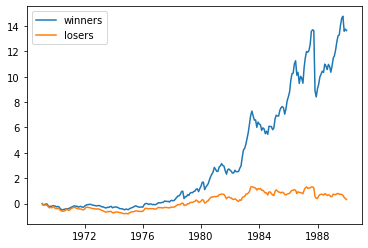

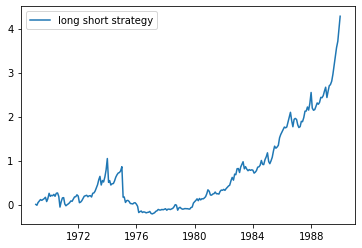

In [25]:
#  6)  Plot the results

# =============================================================================
# Plot the winner loser portfolio and long-short strategy
# =============================================================================
plt.plot(ewretdat3['cumret_winners'])
plt.plot(ewretdat3['cumret_losers'])
plt.legend(['winners','losers'],loc='upper left')
plt.savefig('winners_losers.pdf')
plt.show()
plt.close()

plt.plot(ewretdat3['cumret_long_short'])
plt.legend(['long short strategy'],loc='upper left')
plt.savefig('long_short.pdf')
plt.show()
plt.close()